In [103]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import math
import ast
from scipy.optimize import curve_fit
from shapely.geometry import LineString
import seaborn as sns
sns.set_style("whitegrid")
import shapely as shapely
from scipy.optimize import minimize

In [104]:
def SingleEscapeSort(dataframe):
    dataframe = dataframe.drop('Unnamed: 0', axis=1)
    # if b==True:
    #     dataframe = dataframe.drop('10', axis=1)
    col = dataframe.pop("NTD")
    col2 = dataframe.pop('EnergyV')
    col3 = dataframe.pop('ChannelV')
    col4 = dataframe.pop('Neighbors')
    dataframe.insert(9, col2.name, col2)
    dataframe.insert(15, col.name, col)
    dataframe.insert(10, col3.name, col3)
    dataframe.insert(14, col4.name, col4)
    
    dataframe3 = dataframe[(dataframe['Multiplicity'] == 3)]
    dataframe3['EnergyV']=dataframe3['EnergyV'].apply(ast.literal_eval)
    dataframe3['ChannelV']=dataframe3['ChannelV'].apply(ast.literal_eval)
    dataframe3['NTD']=dataframe3['NTD'].apply(ast.literal_eval)
    dataframe3['Neighbors']=dataframe3['Neighbors'].apply(ast.literal_eval)
    
    rid3 = []
    dataframe3=dataframe3.reset_index(drop=True)
    for i in range(len(dataframe3)):
        if (2070<= dataframe3.iloc[i,9][2]< 2130):
            rid3.append(i)
            
    dataframe3_2100 = dataframe3[dataframe3.index.isin(rid3)]
    dataframe3_2100=dataframe3_2100.reset_index(drop=True)
    
    return dataframe3_2100

def NTD_Sort(dataframe_1tonne_single):
    NTD_data = []
    no_NTD_data = []

    NTD_data = []

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][j] in dataframe_1tonne_single.iloc[i,17]:
                NTD_data.append(i) 

    NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(NTD_data)]
    NTD_data=NTD_data.reset_index(drop=True)

    for i in range(len(dataframe_1tonne_single)):
        for j in range(len(dataframe_1tonne_single.iloc[i,10])):
            if dataframe_1tonne_single.iloc[i,10][0] and dataframe_1tonne_single.iloc[i,10][1] and dataframe_1tonne_single.iloc[i,10][2] not in dataframe_1tonne_single.iloc[i,17]:
                no_NTD_data.append(i) 

    no_NTD_data = dataframe_1tonne_single[dataframe_1tonne_single.index.isin(no_NTD_data)]
    no_NTD_data=no_NTD_data.reset_index(drop=True)
    
    return NTD_data, no_NTD_data

def Topology_Sort(no_NTD_data):
    FC = []
    CE = []
    NC = []
    FN = []
    NE = []
    FF = []
    CC = []
    EE = []
    NN = []
    FE = []
    O = []

    for i in range(len(no_NTD_data)):
        if no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CF' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FC':
            FC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EC':
            CE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NC' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CN':
            NC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FN' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NF':
            FN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EN':
            NE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FF':
            FF.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'CC':
            CC.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EE':
            EE.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'NN':
            NN.append(i)
        elif no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'FE' or no_NTD_data.iloc[i,14][0][0] + no_NTD_data.iloc[i,14][1][0] == 'EF':
            FE.append(i)
        else:
            O.append(i)

    FC = no_NTD_data[no_NTD_data.index.isin(FC)]
    CE = no_NTD_data[no_NTD_data.index.isin(CE)]
    NC = no_NTD_data[no_NTD_data.index.isin(NC)]
    FN = no_NTD_data[no_NTD_data.index.isin(FN)]
    NE = no_NTD_data[no_NTD_data.index.isin(NE)]
    FF = no_NTD_data[no_NTD_data.index.isin(FF)]
    CC = no_NTD_data[no_NTD_data.index.isin(CC)]
    EE = no_NTD_data[no_NTD_data.index.isin(EE)]
    NN = no_NTD_data[no_NTD_data.index.isin(NN)]
    FE = no_NTD_data[no_NTD_data.index.isin(FE)]

    FC =FC.reset_index(drop=True)
    CE =CE.reset_index(drop=True)
    NC =NC.reset_index(drop=True)
    FN =FN.reset_index(drop=True)
    NE =NE.reset_index(drop=True)
    FF =FF.reset_index(drop=True)
    CC =CC.reset_index(drop=True)
    EE =EE.reset_index(drop=True)
    NN =NN.reset_index(drop=True)
    FE =FE.reset_index(drop=True)
    return FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O

def PrimarySecondarySplit(dataframe_1tonne_double):
    total_2100 = []
    total_511 = []

    for i in range(len(dataframe_1tonne_double)):
        total_511.append(dataframe_1tonne_double.iloc[i,9][0] + dataframe_1tonne_double.iloc[i,9][1])
        total_2100.append(dataframe_1tonne_double.iloc[i,9][2])
        
    return np.asarray(total_2100), np.asarray(total_511)

In [1]:
dataframe = pd.read_csv('NTDs_2590_2625_q_tree_call-2tonne.csv', sep = ',', header=0)
dataframe_single = SingleEscapeSort(dataframe)

NTD_single, no_NTD_single = NTD_Sort(dataframe_single)
FC_NTD, CE_NTD, NC_NTD, FN_NTD, NE_NTD, FF_NTD, CC_NTD, EE_NTD, NN_NTD, FE_NTD, O_NTD = Topology_Sort(NTD_single)
FC, CE, NC, FN, NE, FF, CC, EE, NN, FE, O = Topology_Sort(no_NTD_single)

NTD_events = pd.concat([FC_NTD, FN_NTD, FF_NTD, FE_NTD])
NTD_2100, NTD_511 = PrimarySecondarySplit(NTD_events)

CE = pd.concat([CE, CE_NTD])
NC = pd.concat([NC, NC_NTD])
NE = pd.concat([NE, NE_NTD])
CC = pd.concat([CC, CC_NTD])
EE = pd.concat([EE, EE_NTD])
NN = pd.concat([NN, NN_NTD])

NonNTDevents = pd.concat([FC, CE, NC, FN, NE, FF, CC, EE, NN, FE])
NonNTD_2100, NonNTD_511 = PrimarySecondarySplit(NonNTDevents)

NameError: name 'pd' is not defined

In [145]:
# def NormGuassianLinear(x,mu,sigma,A,f, E0, E1):
#     Ec = (E0+E1)/2
#     p = (1+A*(x-Ec))/(E1-E0)
#     return (1-f)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+f*p

# def NegLogLikelihoodGuassLinear(params,data):
#     mu,sigma, A,f = params
#     E0 = min(data)
#     E1 = max(data)
#     LogL = 0
#     for k in data:
#         x = NormGuassianLinear(k,mu,sigma,A,f, E0, E1)
#         if x > 0:
#             LogL += np.log(x)
#     return -2*LogL

# def MinimizeNegLogLikelihoodGuassLinear(data, initial_params):
#     E0 = min(data)
#     E1 = max(data)
#     Ec = (E0+E1)/2
#     bound_A = 1/(Ec-E0)
#     result = minimize(NegLogLikelihoodGuassLinear, initial_params, args=(data),
#                       method='Nelder-Mead', bounds=[(0, None), (0, None),(-bound_A, bound_A) ,(0,1)])
#     return result.x

def NormGuassianLinear(x,mu,mu2,sigma,sigma2,A,f,d, E0, E1):
    Ec = (E0+E1)/2
    p = (1+A*(x-Ec))/(E1-E0)
    return (1-f-d)*((np.exp(-(x-mu)**2/(2*sigma**2)))/np.sqrt(2*np.pi*sigma**2))+f*p + d*((np.exp(-(x-mu2)**2/(2*sigma2**2)))/np.sqrt(2*np.pi*sigma2**2))

def NegLogLikelihoodGuassLinear(params,data):
    mu,mu2,sigma,sigma2, A,f,d = params
    E0 = min(data)
    E1 = max(data)
    x = NormGuassianLinear(data,mu,mu2,sigma,sigma2,A,f,d, E0, E1)
    x = x[x > 0]
    LogL = np.sum(np.log(x))
    return -2*LogL

def MinimizeNegLogLikelihoodGuassLinear(data, initial_params):
    E0 = min(data)
    E1 = max(data)
    Ec = (E0+E1)/2
    bound_A = 1/(Ec-E0)
    result = minimize(NegLogLikelihoodGuassLinear, initial_params, args=(data),
                      method='Nelder-Mead', bounds=[(0, None), (0,2102), (0, None),(0, None),(-bound_A, bound_A) ,(0,1), (0,0.1)])
    return result.x

def Chi2(data, mu_fit, mu2_fit, sigma_fit,sigma2_fit, A_fit, f_fit,d_fit):
    bin_num = 60
    hist, bins = np.histogram(data, bin_num)
    bin_width = (max(data) - min(data))/bin_num

    bin_centers = (bins[:-1] + bins[1:]) / 2

    fitted_pdf = NormGuassianLinear(bin_centers, mu_fit, mu2_fit, sigma_fit,sigma2_fit, A_fit, f_fit,d_fit, min(data), max(data))*len(data)*bin_width

    chi2 = np.sum((hist-fitted_pdf)**2/fitted_pdf)
    
    return chi2

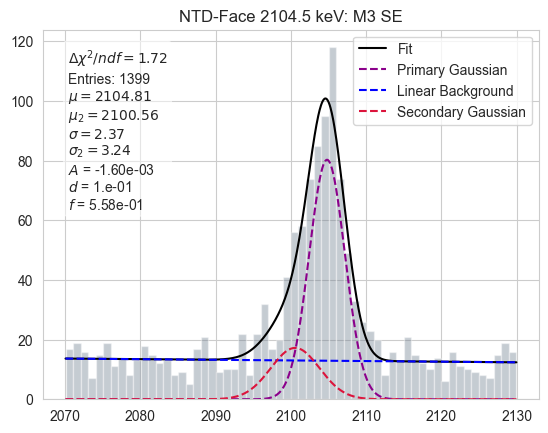

In [146]:
mu = 2104.191035205703
mu2 = 2095
sigma = 2.883115930643209
sigma2 = 2.883115930643209
A = 6.89713150e-03
f = 0.5
d = 0.1
initial_parms = [mu, mu2, sigma, sigma2, A,f, d]
mu_fit, mu2_fit, sigma_fit, sigma2_fit, A_fit, f_fit, d_fit = MinimizeNegLogLikelihoodGuassLinear(NTD_2100, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(NTD_2100), max(NTD_2100), 1000)
bin_num = 60
bin_width = (max(x_values) - min(x_values))/bin_num

fitted_pdf = (NormGuassianLinear(x_values, mu_fit, mu2_fit, sigma_fit, sigma2_fit, A_fit, f_fit, d_fit, min(x_values), max(x_values)))*len(NTD_2100)*bin_width

fig, ax = plt.subplots()
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textF = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NTD_2100, mu_fit, mu2_fit, sigma_fit, sigma2_fit,A_fit, f_fit, d_fit)/53, ),
    'Entries: ' + (str(len(NTD_2100))),
    r'$\mu=%.2f$' % (mu_fit, ),
    r'$\mu_2=%.2f$' % (mu2_fit, ),
    r'$\sigma=%.2f$' % (sigma_fit, ),
    r'$\sigma_2=%.2f$' % (sigma2_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(A_fit, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(d_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(f_fit, precision = 2), )))

ax.plot(x_values, fitted_pdf,label='Fit', color='black')
ax.plot(x_values, (1-f_fit-d_fit)*((np.exp(-(x_values-mu_fit)**2/(2*sigma_fit**2)))/np.sqrt(2*np.pi*sigma_fit**2))*len(NTD_2100)*bin_width, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_values, (f_fit*(1+A_fit*(x_values-((min(NTD_2100)+max(NTD_2100))/2)))/(max(NTD_2100)-min(NTD_2100)))*len(NTD_2100)*bin_width, label = 'Linear Background', linestyle='--', color='blue')
ax.plot(x_values, d_fit*((np.exp(-(x_values-mu2_fit)**2/(2*sigma2_fit**2)))/np.sqrt(2*np.pi*sigma2_fit**2))*len(NTD_2100)*bin_width, label='Secondary Gaussian', linestyle = '--', color='crimson')

ax.hist(NTD_2100, bins = 60 , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textF, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('NTD-Face 2104.5 keV: M3 SE')
ax.legend()

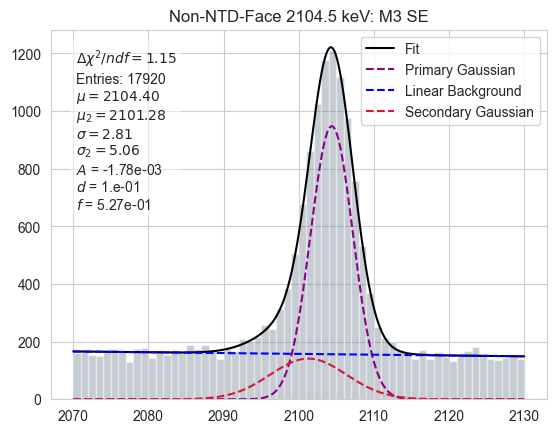

In [140]:

# for purposes of the 2100 keV fit the non-face NTD topologies get sorted into the Non-NTD topologies
        
muNonNTD = 2104.191035205703
mu2NonNTD = 2095
sigmaNonNTD = 2.883115930643209
sigma2NonNTD = 2.883115930643209
ANonNTD = 6.89713150e-03
fNonNTD = 0.5
dNonNTD = 0.1

initial_parms = [muNonNTD, mu2NonNTD, sigmaNonNTD, sigma2NonNTD, ANonNTD,fNonNTD, dNonNTD]

mu_fitNoNTD, mu2_fitNoNTD, sigma_fitNoNTD, sigma2_fitNoNTD, A_fitNoNTD, f_fitNoNTD, d_fitNoNTD = MinimizeNegLogLikelihoodGuassLinear(NonNTD_2100, initial_parms)
# print(f"Fitted parameters: {fitted_params}")
x_values = np.linspace(min(NonNTD_2100), max(NonNTD_2100), 1000)
bin_num = 60
bin_width = (max(x_values) - min(x_values))/bin_num

x_valuesNoNTD = np.linspace(min(NonNTD_2100), max(NonNTD_2100), 1000)

fitted_pdfNoNTD = NormGuassianLinear(x_valuesNoNTD, mu_fitNoNTD, mu2_fitNoNTD, sigma_fitNoNTD, sigma2_fitNoNTD, A_fitNoNTD, f_fitNoNTD, d_fitNoNTD,min(x_values), max(x_values))*len(NonNTD_2100)*bin_width

fig, ax = plt.subplots()
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
textNoNTD = '\n'.join((r'$\Delta\chi^2/ndf=%.2f$' % (Chi2(NonNTD_2100, mu_fitNoNTD, mu2_fitNoNTD, sigma_fitNoNTD, sigma2_fitNoNTD,A_fitNoNTD, f_fitNoNTD, d_fitNoNTD)/53, ),
    'Entries: ' + (str(len(NonNTD_2100))),
    r'$\mu=%.2f$' % (mu_fitNoNTD, ),
    r'$\mu_2=%.2f$' % (mu2_fitNoNTD, ),
    r'$\sigma=%.2f$' % (sigma_fitNoNTD, ),
    r'$\sigma_2=%.2f$' % (sigma2_fitNoNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(A_fitNoNTD, precision = 2), ),
    r'$d$ = ' + str(np.format_float_scientific(d_fitNoNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(f_fitNoNTD, precision = 2), )))

ax.plot(x_valuesNoNTD, fitted_pdfNoNTD,label='Fit', color='black')
ax.plot(x_valuesNoNTD, (1-f_fitNoNTD-d_fitNoNTD)*((np.exp(-(x_valuesNoNTD-mu_fitNoNTD)**2/(2*sigma_fitNoNTD**2)))/np.sqrt(2*np.pi*sigma_fitNoNTD**2))*len(NonNTD_2100)*bin_width, label = 'Primary Gaussian', linestyle='--', color='darkmagenta')
ax.plot(x_valuesNoNTD, (f_fitNoNTD*(1+A_fitNoNTD*(x_valuesNoNTD-((min(NonNTD_2100)+max(NonNTD_2100))/2)))/(max(NonNTD_2100)-min(NonNTD_2100)))*len(NonNTD_2100)*bin_width, label = 'Linear Background', linestyle='--', color='blue')
ax.plot(x_valuesNoNTD, d_fitNoNTD*((np.exp(-(x_valuesNoNTD-mu2_fitNoNTD)**2/(2*sigma2_fitNoNTD**2)))/np.sqrt(2*np.pi*sigma2_fitNoNTD**2))*len(NonNTD_2100)*bin_width, label='Secondary Gaussian', linestyle = '--', color='crimson')

ax.hist(NonNTD_2100, bins = 60 , color='slategray', alpha=0.4)
ax.text(0.05, 0.95, textNoNTD, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax.set_title('Non-NTD-Face 2104.5 keV: M3 SE')
ax.legend()

In [144]:
FC_2100, FC_511 = PrimarySecondarySplit(FC)
CE_2100, CE_511 = PrimarySecondarySplit(CE)
NC_2100, NC_511 = PrimarySecondarySplit(NC)
FN_2100, FN_511 = PrimarySecondarySplit(FN)
NE_2100, NE_511 = PrimarySecondarySplit(NE)
FF_2100, FF_511 = PrimarySecondarySplit(FF)
# CC_2100, CC_511 = PrimarySecondarySplit(CC) not enough events to fit anything
EE_2100, EE_511 = PrimarySecondarySplit(EE)
NN_2100, NN_511 = PrimarySecondarySplit(NN)
FE_2100, FE_511 = PrimarySecondarySplit(FE)


FC_2100NTD, FC_511NTD = PrimarySecondarySplit(FC_NTD)
FN_2100NTD, FN_511NTD = PrimarySecondarySplit(FN_NTD)
FF_2100NTD, FF_511NTD = PrimarySecondarySplit(FF_NTD)
FE_2100NTD, FE_511NTD = PrimarySecondarySplit(FE_NTD)


FC_initial_2100 = [2.10420591e+3, 2095, 3.25076564,3.25076564, 6.62930626/3.57543524e+2, 0.5, 0.1]
CE_initial_2100 = [2.10431458e+3,  2095, 2.98706007,2.98706007, 6.95816602/5.28868090e+2, 0.5, 0.1]
NC_initial_2100 = [2.10408443e+3, 2095, 3.10887194, 3.10887194, 4.64167835/4.14757903e+2, 0.5, 0.1]
FN_initial_2100 = [2.10446511e+3, 2095, 3.16498578, 3.16498578, 1.42947997e+1/5.31468025e+2, 0.5, 0.1]
NE_initial_2100 = [2.10428559e+3, 2095, 3.08138163,  3.08138163,1.18973642e+1/7.92020460e+2, 0.5, 0.1]
FF_initial_2100 = [2.10384220e+3, 2095, 2.94879678, 2.94879678,7.39805739/2.92487903e+2, 0.5, 0.1]
EE_initial_2100 = [2.10429581e+3, 2095, 3.18361783, 3.18361783, 3.07702572/1.82678290e+2, 0.5, 0.1]
NN_initial_2100 = [2.10440454e+3, 2095, 3.35752216, 3.35752216,1.79403180/1.31148969e+2, 0.5, 0.1]
FE_initial_2100 = [2.10397686e+3, 2095, 3.00489800, 3.00489800, 2.50052853/1.66988732e+2, 0.5, 0.1]

FCmu_fit, FCmu2_fit, FCsigma_fit, FCsigma2_fit, FCA_fit, FCf_fit, FCd_fit = MinimizeNegLogLikelihoodGuassLinear(FC_2100, FC_initial_2100)
CEmu_fit, CEmu2_fit, CEsigma_fit, CEsigma2_fit, CEA_fit, CEf_fit, CEd_fit = MinimizeNegLogLikelihoodGuassLinear(CE_2100, CE_initial_2100)
NCmu_fit, NCmu2_fit, NCsigma_fit, NCsigma2_fit, NCA_fit, NCf_fit, NCd_fit = MinimizeNegLogLikelihoodGuassLinear(NC_2100, NC_initial_2100)
FNmu_fit, FNmu2_fit, FNsigma_fit, FNsigma2_fit, FNA_fit, FNf_fit, FNd_fit = MinimizeNegLogLikelihoodGuassLinear(FN_2100, FN_initial_2100)
NEmu_fit, NEmu2_fit, NEsigma_fit, NEsigma2_fit, NEA_fit, NEf_fit, NEd_fit = MinimizeNegLogLikelihoodGuassLinear(NE_2100, NE_initial_2100)
FFmu_fit, FFmu2_fit, FFsigma_fit, FFsigma2_fit, FFA_fit, FFf_fit, FFd_fit = MinimizeNegLogLikelihoodGuassLinear(FF_2100, FF_initial_2100)
EEmu_fit, EEmu2_fit, EEsigma_fit, EEsigma2_fit, EEA_fit, EEf_fit, EEd_fit = MinimizeNegLogLikelihoodGuassLinear(EE_2100, EE_initial_2100)
NNmu_fit, NNmu2_fit, NNsigma_fit, NNsigma2_fit, NNA_fit, NNf_fit, NNd_fit = MinimizeNegLogLikelihoodGuassLinear(NN_2100, NN_initial_2100)
FEmu_fit, FEmu2_fit, FEsigma_fit, FEsigma2_fit, FEA_fit, FEf_fit, FEd_fit = MinimizeNegLogLikelihoodGuassLinear(FE_2100, FE_initial_2100)

FC_initial_2100NTD = [2.10342955e+03, 2095, 3.63130053e+00, 3.63130053e+00, 2.62135783e+00/8.11034707e+2, 0.5, 0.1]
FN_initial_2100NTD = [ 2.10456843e+03, 2095, 3.23366653e+00, 3.23366653e+00, 2.06372015e+00/1.22944665e+02,0.5, 0.1]
FF_initial_2100NTD = [2.10510104e+03,  2095, 1.53677534e+00, 1.53677534e+00, 4.18592268e+00/1.86227185e+02,0.5, 0.1]
FE_initial_2100NTD = [2.10431740e+03, 2095, 2.64476582e+00, 2.64476582e+00, 4.23619557e+00/3.38125388e+02,0.5, 0.1]

FCmu_fitNTD, FCmu2_fitNTD, FCsigma_fitNTD, FCsigma2_fitNTD, FCA_fitNTD, FCf_fitNTD, FCd_fitNTD = MinimizeNegLogLikelihoodGuassLinear(FC_2100NTD, FC_initial_2100NTD)
FNmu_fitNTD, FNmu2_fitNTD, FNsigma_fitNTD, FNsigma2_fitNTD, FNA_fitNTD, FNf_fitNTD, FNd_fitNTD = MinimizeNegLogLikelihoodGuassLinear(FN_2100NTD, FN_initial_2100NTD)
FFmu_fitNTD, FFmu2_fitNTD, FFsigma_fitNTD, FFsigma2_fitNTD, FFA_fitNTD, FFf_fitNTD, FFd_fitNTD = MinimizeNegLogLikelihoodGuassLinear(FF_2100NTD, FF_initial_2100NTD)
FEmu_fitNTD, FEmu2_fitNTD, FEsigma_fitNTD, FEsigma2_fitNTD, FEA_fitNTD, FEf_fitNTD, FEd_fitNTD = MinimizeNegLogLikelihoodGuassLinear(FE_2100NTD, FE_initial_2100NTD)

In [111]:
def Graph_2100(data, mu_fit, sigma_fit, A_fit, f_fit):
    x_values = np.linspace(min(data), max(data), 1000)
    fitted_pdf = NormGuassianLinear(x_values, mu_fit, mu2_fit, sigma_fit, sigma2_fit, A_fit, f_fit, d_fit, min(x_values), max(x_values))*len(data)
    return x_values, fitted_pdf
FCx, FC_fit = Graph_2100(FC_2100, FCmu_fit, FCsigma_fit, FCA_fit, FCf_fit)
CEx, CE_fit = Graph_2100(CE_2100, CEmu_fit, CEsigma_fit, CEA_fit, CEf_fit)
NCx, NC_fit = Graph_2100(NC_2100, NCmu_fit, NCsigma_fit, NCA_fit, NCf_fit)
FNx, FN_fit = Graph_2100(FN_2100, FNmu_fit, FNsigma_fit, FNA_fit, FNf_fit)
NEx, NE_fit = Graph_2100(NE_2100, NEmu_fit, NEsigma_fit, NEA_fit, NEf_fit)
FFx, FF_fit = Graph_2100(FF_2100, FFmu_fit, FFsigma_fit, FFA_fit, FFf_fit)
EEx, EE_fit = Graph_2100(EE_2100, EEmu_fit, EEsigma_fit, EEA_fit, EEf_fit)
NNx, NN_fit = Graph_2100(NN_2100, NNmu_fit, NNsigma_fit, NNA_fit, NNf_fit)
FEx, FE_fit = Graph_2100(FE_2100, FEmu_fit, FEsigma_fit, FEA_fit, FEf_fit)

FCxNTD, FC_fitNTD = Graph_2100(FC_2100NTD, FCmu_fitNTD, FCsigma_fitNTD, FCA_fitNTD, FCf_fitNTD)
FNxNTD, FN_fitNTD = Graph_2100(FN_2100NTD, FNmu_fitNTD, FNsigma_fitNTD, FNA_fitNTD, FNf_fitNTD)
FFxNTD, FF_fitNTD = Graph_2100(FF_2100NTD, FFmu_fitNTD, FFsigma_fitNTD, FFA_fitNTD, FFf_fitNTD)
FExNTD, FE_fitNTD = Graph_2100(FE_2100NTD, FEmu_fitNTD, FEsigma_fitNTD, FEA_fitNTD, FEf_fitNTD)

Text(0.5, 1.0, 'FE')

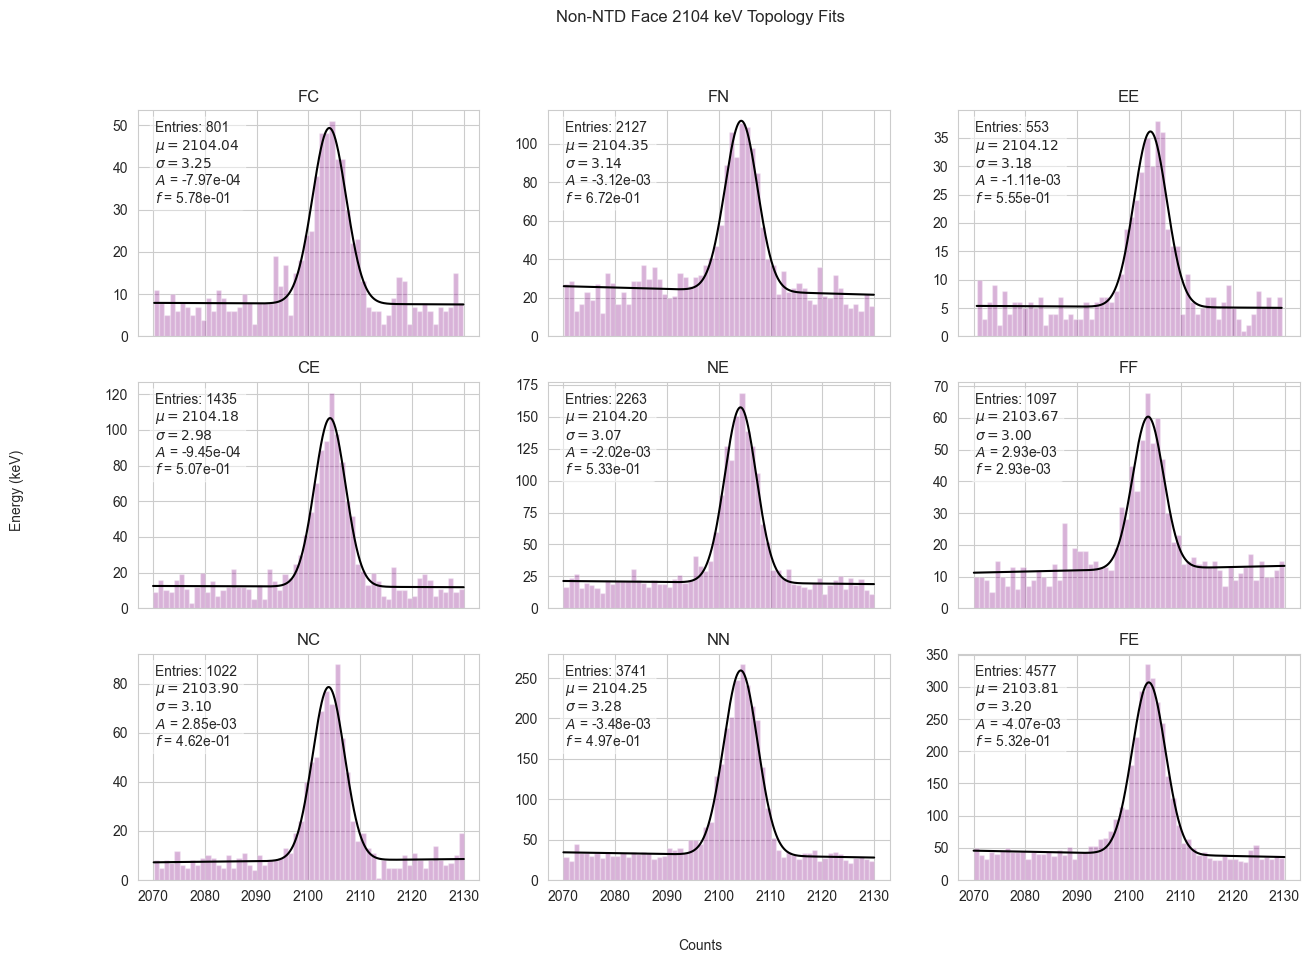

In [127]:
fig, ax = plt.subplots(3,3, sharex='col', figsize=(15, 10))
fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('Non-NTD Face 2104 keV Topology Fits')

textFC = '\n'.join(('Entries: ' + (str(len(FC_2100))),
    r'$\mu=%.2f$' % (FCmu_fit, ),
    r'$\sigma=%.2f$' % (FCsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FCA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FCf_fit, precision = 2), )))

ax[0,0].plot(FCx, FC_fit,label='FC Fit', color='black')
ax[0,0].hist(FC_2100, bins = 60 , alpha=0.3, color='purple')
ax[0,0].text(0.05, 0.95, textFC, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
##############
textCE = '\n'.join(('Entries: ' + (str(len(CE_2100))),
    r'$\mu=%.2f$' % (CEmu_fit, ),
    r'$\sigma=%.2f$' % (CEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(CEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(CEf_fit, precision = 2), )))

ax[1,0].plot(CEx, CE_fit, color='black')
ax[1,0].hist(CE_2100, bins = 60 , alpha=0.3, color='purple')
ax[1,0].text(0.05, 0.95, textCE, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('CE')
#######
textNC = '\n'.join(('Entries: ' + (str(len(NC_2100))),
    r'$\mu=%.2f$' % (NCmu_fit, ),
    r'$\sigma=%.2f$' % (NCsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NCA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NCf_fit, precision = 2), )))

ax[2,0].plot(NCx, NC_fit, color='black')
ax[2,0].hist(NC_2100, bins = 60 , alpha=0.3, color='purple')
ax[2,0].text(0.05, 0.95, textNC, transform=ax[2,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,0].set_title('NC')
########
textFN = '\n'.join(('Entries: ' + (str(len(FN_2100))),
    r'$\mu=%.2f$' % (FNmu_fit, ),
    r'$\sigma=%.2f$' % (FNsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FNA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FNf_fit, precision = 2), )))

ax[0,1].plot(FNx, FN_fit, color='black')
ax[0,1].hist(FN_2100, bins = 60 , alpha=0.3, color='purple')
ax[0,1].text(0.05, 0.95, textFN, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FN')
########
textNE = '\n'.join(('Entries: ' + (str(len(NE_2100))),
    r'$\mu=%.2f$' % (NEmu_fit, ),
    r'$\sigma=%.2f$' % (NEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NEf_fit, precision = 2), )))

ax[1,1].plot(NEx, NE_fit, color='black')
ax[1,1].hist(NE_2100, bins = 60 , alpha=0.3, color='purple')
ax[1,1].text(0.05, 0.95, textNE, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('NE')
########
textFF = '\n'.join(('Entries: ' + (str(len(FF_2100))),
    r'$\mu=%.2f$' % (FFmu_fit, ),
    r'$\sigma=%.2f$' % (FFsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FFA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FFA_fit, precision = 2), )))

ax[1,2].plot(FFx, FF_fit, color='black')
ax[1,2].hist(FF_2100, bins = 60 , alpha=0.3, color='purple')
ax[1,2].text(0.05, 0.95, textFF, transform=ax[1,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,2].set_title('FF')
########
textEE = '\n'.join(('Entries: ' + (str(len(EE_2100))),
    r'$\mu=%.2f$' % (EEmu_fit, ),
    r'$\sigma=%.2f$' % (EEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(EEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(EEf_fit, precision = 2), )))

ax[0,2].plot(EEx, EE_fit, color='black')
ax[0,2].hist(EE_2100, bins = 60 , alpha=0.3, color='purple')
ax[0,2].text(0.05, 0.95, textEE, transform=ax[0,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,2].set_title('EE')
########
textNN = '\n'.join(('Entries: ' + (str(len(NN_2100))),
    r'$\mu=%.2f$' % (NNmu_fit, ),
    r'$\sigma=%.2f$' % (NNsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(NNA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(NNf_fit, precision = 2), )))

ax[2,1].plot(NNx, NN_fit, color='black')
ax[2,1].hist(NN_2100, bins = 60 , alpha=0.3, color='purple')
ax[2,1].text(0.05, 0.95, textNN, transform=ax[2,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,1].set_title('NN')
########
textFE = '\n'.join(('Entries: ' + (str(len(FE_2100))),
    r'$\mu=%.2f$' % (FEmu_fit, ),
    r'$\sigma=%.2f$' % (FEsigma_fit, ),
    r'$A$ = ' + str(np.format_float_scientific(FEA_fit, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FEf_fit, precision = 2), )))

ax[2,2].plot(FEx, FE_fit, color='black')
ax[2,2].hist(FE_2100, bins = 60 , alpha=0.3, color='purple')
ax[2,2].text(0.05, 0.95, textFE, transform=ax[2,2].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[2,2].set_title('FE')

Text(0.5, 1.0, 'FE')

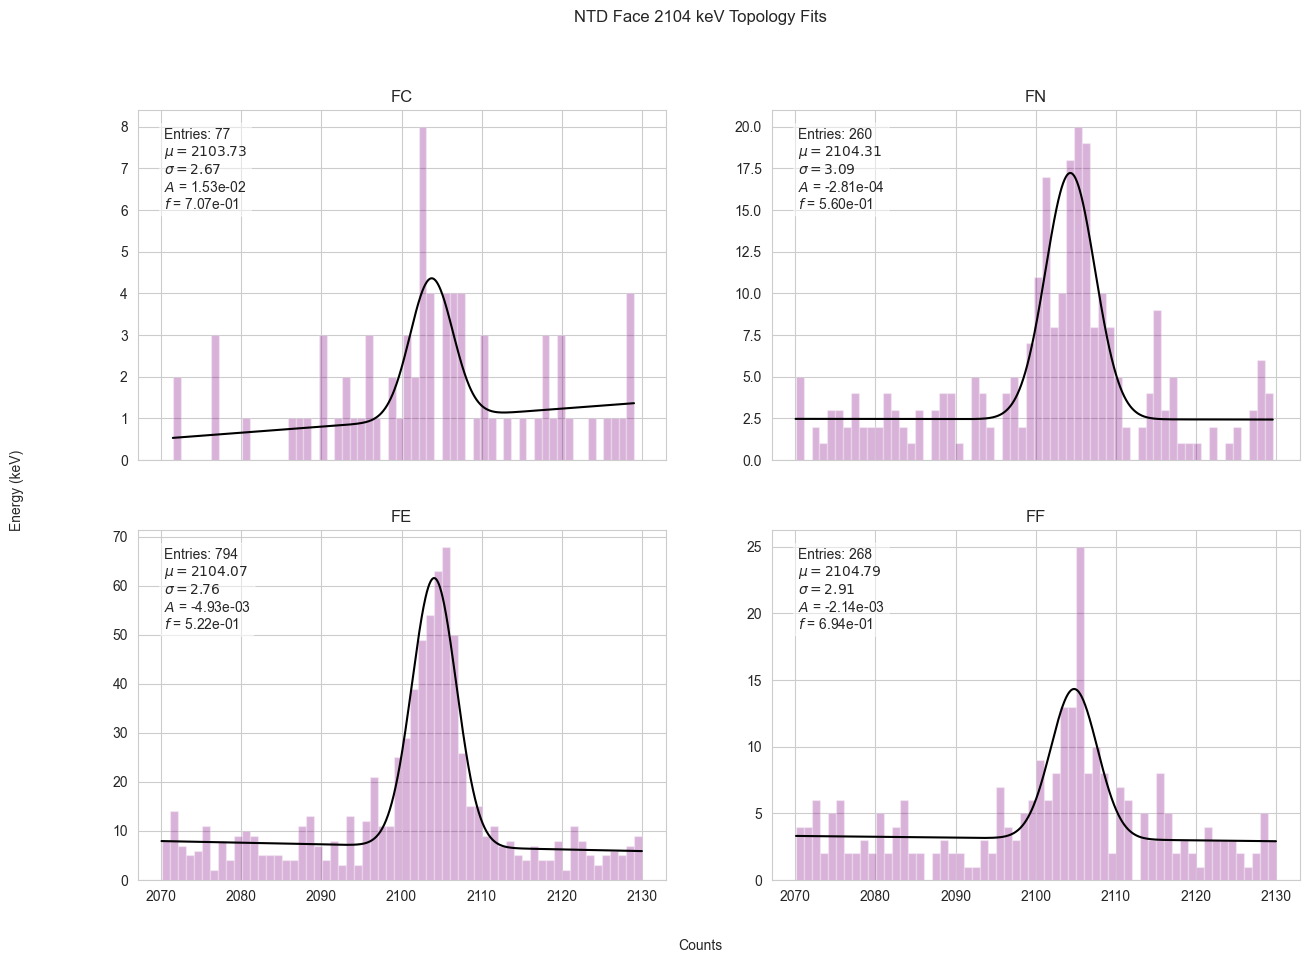

In [128]:
fig, ax = plt.subplots(2,2, sharex='col', figsize=(15, 10))
fig.text(0.04, 0.5, 'Energy (keV)', va='center', rotation = 'vertical')
fig.text(0.5, 0.04, 'Counts', ha='center')
props = dict(boxstyle='round', facecolor='white', alpha=0.5)
fig.suptitle('NTD Face 2104 keV Topology Fits')

textFCNTD = '\n'.join(('Entries: ' + (str(len(FC_2100NTD))),
    r'$\mu=%.2f$' % (FCmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FCsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FCA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FCf_fitNTD, precision = 2), )))

ax[0,0].plot(FCxNTD, FC_fitNTD,label='FC Fit', color='black')
ax[0,0].hist(FC_2100NTD, bins = 60, alpha=0.3, color='purple')
ax[0,0].text(0.05, 0.95, textFCNTD, transform=ax[0,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,0].set_title('FC')
##############

textFNNTD = '\n'.join(('Entries: ' + (str(len(FN_2100NTD))),
    r'$\mu=%.2f$' % (FNmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FNsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FNA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FNf_fitNTD, precision = 2), )))

ax[0,1].plot(FNxNTD, FN_fitNTD, color='black')
ax[0,1].hist(FN_2100NTD, bins = 60, alpha=0.3, color='purple')
ax[0,1].text(0.05, 0.95, textFNNTD, transform=ax[0,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[0,1].set_title('FN')
########
textFFNTD = '\n'.join(('Entries: ' + (str(len(FF_2100NTD))),
    r'$\mu=%.2f$' % (FFmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FFsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FFA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FFf_fitNTD, precision = 2), )))

ax[1,1].plot(FFxNTD, FF_fitNTD, color='black')
ax[1,1].hist(FF_2100NTD, bins = 60, alpha=0.3, color='purple')
ax[1,1].text(0.05, 0.95, textFFNTD, transform=ax[1,1].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,1].set_title('FF')
#########
textFENTD = '\n'.join(('Entries: ' + (str(len(FE_2100NTD))),
    r'$\mu=%.2f$' % (FEmu_fitNTD, ),
    r'$\sigma=%.2f$' % (FEsigma_fitNTD, ),
    r'$A$ = ' + str(np.format_float_scientific(FEA_fitNTD, precision = 2), ),
r'$f$ = ' + str(np.format_float_scientific(FEf_fitNTD, precision = 2), )))

ax[1,0].plot(FExNTD, FE_fitNTD, color='black')
ax[1,0].hist(FE_2100NTD, bins = 60, alpha=0.3, color='purple')
ax[1,0].text(0.05, 0.95, textFENTD, transform=ax[1,0].transAxes, fontsize=10,
        verticalalignment='top', bbox=props)
ax[1,0].set_title('FE')

In [114]:
def NegLogLikelihoodGuassExp(params,data):
    mu,sigma, A, f = params
    E0 = min(data)
    E1 = max(data)
    LogL = 0
    for k in data:
        x = NormGuassianLinear(k,mu,sigma,A,f, E0, E1)
        # if x > 0:
        LogL += np.log(x)
    return -2*LogL

def Uncertainity(data, mu, sigma,A,f):
    params = [mu, sigma, A, f]
    arr1 = NegLogLikelihoodGuassExp(params, data)
    arr2 = arr1 - min(arr1)
    xaxis = LineString(np.column_stack((arr2,np.linspace(1,1, len(arr2)))))
    if isinstance(mu, float) == False: 
        curve = LineString(np.column_stack((mu, arr2)))
        intersection = xaxis.intersection(curve)
    elif isinstance(mu, float) == True:
        curve = LineString(np.column_stack((sigma, arr2)))
        intersection = curve.intersection(xaxis)
    if str(intersection) == 'LINESTRING Z EMPTY':
        intersection_indices = np.where(np.isclose(arr2, np.linspace(1,1, len(arr2)), atol=0.01))[0]
        intersection = mu[intersection_indices]
        # intersection_y = arr2[intersection_indices]
        # intersection = list(zip(intersection_x, intersection_y))
    return intersection, arr2

def Errors(mu_intersections, means):
    upper_errs = []
    lower_errs = []

    for i in range(len(mu_intersections)):
        if mu_intersections[i][0] < mu_intersections[i][1]:
            upper_errs.append(mu_intersections[i][1])
            lower_errs.append(mu_intersections[i][0])
        else:
            upper_errs.append(mu_intersections[i][0])
            lower_errs.append(mu_intersections[i][1])

    top_errs = []
    bot_errs = []
    for i in range(len(upper_errs)):
        top_errs.append(abs(means[i]-upper_errs[i]))
        bot_errs.append(abs(means[i]-lower_errs[i]))

    asymmetric_errormu = np.array(list(zip(bot_errs, top_errs))).T
    return asymmetric_errormu

In [115]:
FCmu_arr = np.linspace(FCmu_fit-1, FCmu_fit+1, 1000) 
CEmu_arr = np.linspace(CEmu_fit-10, CEmu_fit+10, 1000)
NCmu_arr = np.linspace(NCmu_fit-15, NCmu_fit+15, 10000)
FNmu_arr = np.linspace(FNmu_fit-1, FNmu_fit+1, 1200) 
NEmu_arr = np.linspace(NEmu_fit-10, NEmu_fit+10, 1000)
FFmu_arr = np.linspace(FFmu_fit-1, FFmu_fit+2, 1000) 
EEmu_arr = np.linspace(EEmu_fit-1, EEmu_fit+1, 500) 
NNmu_arr = np.linspace(NNmu_fit-5, NNmu_fit+5, 100)
FEmu_arr = np.linspace(FEmu_fit-5, FEmu_fit+5, 100)

FCintersection_mu, FCerror_mu = Uncertainity(FC_2100, FCmu_arr, FCsigma_fit,FCA_fit,FCf_fit)#
CEintersection_mu, CEerror_mu = Uncertainity(CE_2100, CEmu_arr, CEsigma_fit,CEA_fit,CEf_fit)
NCintersection_mu, NCerror_mu = Uncertainity(NC_2100, NCmu_arr, NCsigma_fit,NCA_fit,NCf_fit)
FNintersection_mu, FNerror_mu = Uncertainity(FN_2100, FNmu_arr, FNsigma_fit,FNA_fit,FNf_fit) #
NEintersection_mu, NEerror_mu = Uncertainity(NE_2100, NEmu_arr, NEsigma_fit,NEA_fit,NEf_fit)
FFintersection_mu, FFerror_mu = Uncertainity(FF_2100, FFmu_arr, FFsigma_fit,FFA_fit,FFf_fit) #
EEintersection_mu, EEerror_mu = Uncertainity(EE_2100, EEmu_arr, EEsigma_fit, EEA_fit, EEf_fit) #
NNintersection_mu, NNerror_mu = Uncertainity(NN_2100, NNmu_arr, NNsigma_fit,NNA_fit,NNf_fit) 
FEintersection_mu, FEerror_mu = Uncertainity(FE_2100, FEmu_arr, FEsigma_fit,FEA_fit,FEf_fit)

FCmu_arrNTD = np.linspace(FCmu_fitNTD-5, FCmu_fitNTD+5, 1000)
FNmu_arrNTD = np.linspace(FNmu_fitNTD-5, FNmu_fitNTD+5, 2000)
FFmu_arrNTD = np.linspace(FFmu_fitNTD-5, FFmu_fitNTD+5, 1000)
FEmu_arrNTD = np.linspace(FEmu_fitNTD-5, FEmu_fitNTD+5, 2000)

FCintersection_muNTD, FCerror_muNTD = Uncertainity(FC_2100NTD, FCmu_arrNTD, FCsigma_fitNTD, FCA_fitNTD, FCf_fitNTD)
FNintersection_muNTD, FNerror_muNTD = Uncertainity(FN_2100NTD, FNmu_arrNTD, FNsigma_fitNTD, FNA_fitNTD, FNf_fitNTD)
FFintersection_muNTD, FFerror_muNTD = Uncertainity(FF_2100NTD, FFmu_arrNTD, FFsigma_fitNTD, FFA_fitNTD, FFf_fitNTD)
FEintersection_muNTD, FEerror_muNTD = Uncertainity(FE_2100NTD, FEmu_arrNTD, FEsigma_fitNTD, FEA_fitNTD, FEf_fitNTD) 

In [116]:
print(FNintersection_muNTD)

[2103.93813612 2104.68350881]


In [117]:
FCsigma_arr = np.linspace(FCsigma_fit/2, FCsigma_fit*2, 100)
CEsigma_arr = np.linspace(CEsigma_fit/2, CEsigma_fit*2, 100)
NCsigma_arr = np.linspace(NCsigma_fit/2, NCsigma_fit*2, 100)
FNsigma_arr = np.linspace(FNsigma_fit/2, FNsigma_fit*2, 100)
NEsigma_arr = np.linspace(NEsigma_fit/2, NEsigma_fit*2, 100)
FFsigma_arr = np.linspace(FFsigma_fit/2, FFsigma_fit*2, 100)
EEsigma_arr = np.linspace(EEsigma_fit/2, EEsigma_fit*2, 100)
NNsigma_arr = np.linspace(NNsigma_fit/2, NNsigma_fit*2, 100)
FEsigma_arr = np.linspace(FEsigma_fit/2, FEsigma_fit*2, 100)

FCintersection_sigma, FCerror_sigma = Uncertainity(FC_2100, FCmu_fit, FCsigma_arr, FCA_fit, FCf_fit)
CEintersection_sigma, CEerror_sigma = Uncertainity(CE_2100, CEmu_fit, CEsigma_arr, CEA_fit, CEf_fit)
NCintersection_sigma, NCerror_sigma = Uncertainity(NC_2100, NCmu_fit, NCsigma_arr, NCA_fit, NCf_fit)
FNintersection_sigma, FNerror_sigma = Uncertainity(FN_2100, FNmu_fit, FNsigma_arr, FNA_fit, FNf_fit)
NEintersection_sigma, NEerror_sigma = Uncertainity(NE_2100, NEmu_fit, NEsigma_arr, NEA_fit, NEf_fit)
FFintersection_sigma, FFerror_sigma = Uncertainity(FF_2100, FFmu_fit, FFsigma_arr, FFA_fit, FFf_fit)
EEintersection_sigma, EEerror_sigma = Uncertainity(EE_2100, EEmu_fit, EEsigma_arr, EEA_fit, EEf_fit)
NNintersection_sigma, NNerror_sigma = Uncertainity(NN_2100, NNmu_fit, NNsigma_arr, NNA_fit, NNf_fit) 
FEintersection_sigma, FEerror_sigma = Uncertainity(FE_2100, FEmu_fit, FEsigma_arr, FEA_fit, FEf_fit) 

FCsigma_arrNTD = np.linspace(FCsigma_fitNTD/2, FCsigma_fitNTD*2, 100)
FNsigma_arrNTD = np.linspace(FNsigma_fitNTD/2, FNsigma_fitNTD*2, 100)
FFsigma_arrNTD = np.linspace(FFsigma_fitNTD/2, FFsigma_fitNTD*2, 100)
FEsigma_arrNTD = np.linspace(FEsigma_fitNTD/2, FEsigma_fitNTD*2, 100)

FCintersection_sigmaNTD, FCerror_sigmaNTD = Uncertainity(FC_2100NTD, FCmu_fitNTD, FCsigma_arrNTD, FCA_fitNTD, FCf_fitNTD)
FNintersection_sigmaNTD, FNerror_sigmaNTD = Uncertainity(FN_2100NTD, FNmu_fitNTD, FNsigma_arrNTD, FNA_fitNTD, FNf_fitNTD)
FFintersection_sigmaNTD, FFerror_sigmaNTD = Uncertainity(FF_2100NTD, FFmu_fitNTD, FFsigma_arrNTD,FFA_fitNTD, FFf_fitNTD)
FEintersection_sigmaNTD, FEerror_sigmaNTD = Uncertainity(FE_2100NTD, FEmu_fitNTD, FEsigma_arrNTD, FEA_fitNTD, FEf_fitNTD)

In [118]:
mu_arr = np.linspace(mu_fit-5, mu_fit+5, 1000)
intersection_mu, error_mu = Uncertainity(NTD_2100, mu_arr, sigma_fit,A_fit,f_fit)
NonNTDmu_arr = np.linspace(NonNTDmu_fit-5, NonNTDmu_fit+5, 1000)
NonNTDintersection_mu, NonNTDerror_mu = Uncertainity(NonNTD_2100, NonNTDmu_arr, NonNTDsigma_fit,NonNTDA_fit,NonNTDf_fit)

In [119]:
sigma_arr = np.linspace(sigma_fit/2, sigma_fit*2, 100)
intersection_sigma, error_sigma = Uncertainity(NTD_2100, mu_fit, sigma_arr,A_fit,f_fit)
NonNTDsigma_arr = np.linspace(NonNTDsigma_fit/2, NonNTDsigma_fit*2, 100)
NonNTDintersection_sigma, NonNTDerror_sigma = Uncertainity(NonNTD_2100, NonNTDmu_fit, NonNTDsigma_arr,NonNTDA_fit,NonNTDf_fit)

Text(0.5, 1.0, 'M3 Single: 2104.5 keV Means')

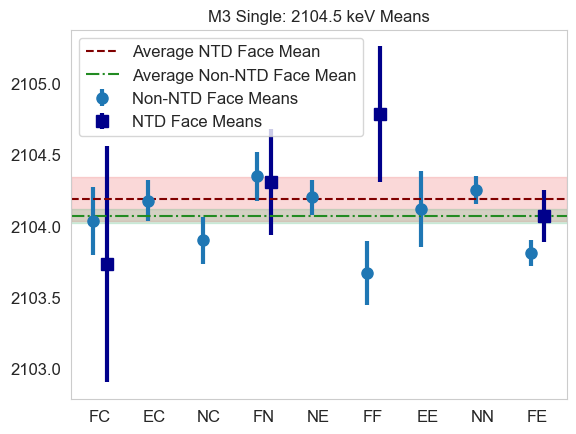

In [120]:
from matplotlib.transforms import Affine2D
topologiesNTD = ['FC','FN','FF','FE']
NTDmeans = [FCmu_fitNTD, FNmu_fitNTD, FFmu_fitNTD, FEmu_fitNTD]

topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
nonNTDmeans = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit]

mu_intersectionsNTD = [FCintersection_muNTD, FNintersection_muNTD,
                   FFintersection_muNTD, FEintersection_muNTD]

mu_intersections = [FCintersection_mu, [CEintersection_mu.geoms[0].x, CEintersection_mu.geoms[1].x], 
                    [NCintersection_mu.geoms[0].x, NCintersection_mu.geoms[1].x],  
                    FNintersection_mu, [NEintersection_mu.geoms[0].x, NEintersection_mu.geoms[1].x], 
                    FFintersection_mu, EEintersection_mu,
                   [NNintersection_mu.geoms[0].x, NNintersection_mu.geoms[1].x], [FEintersection_mu.geoms[0].x,FEintersection_mu.geoms[1].x] ]

ass_errNTD = Errors(mu_intersectionsNTD, NTDmeans)
asymmetric_errormu = Errors(mu_intersections, nonNTDmeans)

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.125, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, nonNTDmeans, yerr=asymmetric_errormu, transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Means')
ax.errorbar(topologiesNTD, NTDmeans, yerr=ass_errNTD, transform=trans2, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Means')

ax.axhspan(intersection_mu[0], intersection_mu[1], color='lightcoral', alpha=0.3)
ax.axhline(mu_fit, color='maroon', linestyle='--', label='Average NTD Face Mean')

ax.axhspan(NonNTDintersection_mu.geoms[0].x, NonNTDintersection_mu.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(NonNTDmu_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Mean')

plt.legend(loc='upper left',fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single: 2104.5 keV Means')

Text(0.5, 1.0, 'M3 Single: 2104.5 keV Standard Dev')

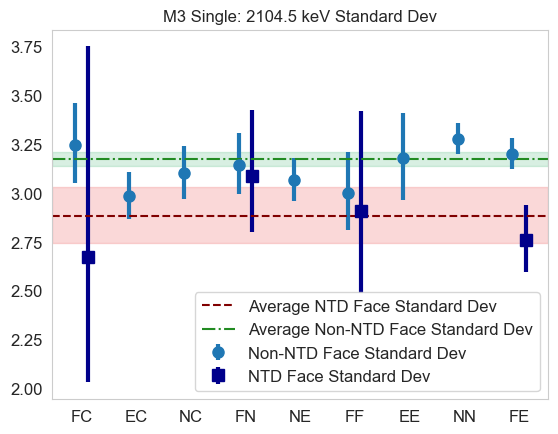

In [121]:
topologiesNTD = ['FC','FN','FF','FE']
NTDsds = [FCsigma_fitNTD, FNsigma_fitNTD, FFsigma_fitNTD, FEsigma_fitNTD]

topologiesNonNTD = ['FC', 'EC', 'NC', 'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
nonNTDsds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit]

sigma_intersections = [[FCintersection_sigma.geoms[0].x, FCintersection_sigma.geoms[1].x], [CEintersection_sigma.geoms[0].x, CEintersection_sigma.geoms[1].x], 
                    [NCintersection_sigma.geoms[0].x, NCintersection_sigma.geoms[1].x],  
                    [FNintersection_sigma.geoms[0].x,FNintersection_sigma.geoms[1].x], [NEintersection_sigma.geoms[0].x, NEintersection_sigma.geoms[1].x], 
                    [FFintersection_sigma.geoms[0].x, FFintersection_sigma.geoms[1].x], [EEintersection_sigma.geoms[0].x, EEintersection_sigma.geoms[1].x],
                   [NNintersection_sigma.geoms[0].x, NNintersection_sigma.geoms[1].x], [FEintersection_sigma.geoms[0].x,FEintersection_sigma.geoms[1].x] ]



sigma_intersectionsNTD = [[FCintersection_sigmaNTD.geoms[0].x, FCintersection_sigmaNTD.geoms[1].x], 
                    [FNintersection_sigmaNTD.geoms[0].x,FNintersection_sigmaNTD.geoms[1].x], 
                    [FFintersection_sigmaNTD.geoms[0].x, FFintersection_sigmaNTD.geoms[1].x],
                   [FEintersection_sigmaNTD.geoms[0].x,FEintersection_sigmaNTD.geoms[1].x] ]

asymmetric_errorNTD = Errors(sigma_intersectionsNTD,NTDsds)
asymmetric_errornonNTD = Errors(sigma_intersections,nonNTDsds)

fig, ax = plt.subplots()
trans1 = Affine2D().translate(-0.12, 0.0) + ax.transData
trans2 = Affine2D().translate(+0.12, 0.0) + ax.transData

ax.errorbar(topologiesNonNTD, nonNTDsds, yerr=asymmetric_errornonNTD, transform=trans1, ms=8, elinewidth=3, fmt='o', label='Non-NTD Face Standard Dev')
ax.errorbar(topologiesNTD, NTDsds, yerr=asymmetric_errorNTD, transform=trans2, fmt='s',ms=8, elinewidth=3, color='darkblue', label='NTD Face Standard Dev')

ax.axhspan(intersection_sigma.geoms[0].x, intersection_sigma.geoms[1].x, color='lightcoral', alpha=0.3)
ax.axhline(sigma_fit, color='maroon', linestyle='--', label='Average NTD Face Standard Dev')

ax.axhspan(NonNTDintersection_sigma.geoms[0].x, NonNTDintersection_sigma.geoms[1].x, color='mediumseagreen', alpha=0.2)
ax.axhline(NonNTDsigma_fit, color='forestgreen', linestyle='-.', label='Average Non-NTD Face Standard Dev')

plt.legend(loc='lower right',fontsize=12)

plt.xticks(fontsize=12);
plt.yticks(fontsize=12);
plt.grid(False)
plt.title('M3 Single: 2104.5 keV Standard Dev')

In [124]:
for i in range(len(nonNTDmeans)):
    print(str(nonNTDmeans[i]) + '-' + str(asymmetric_errormu[0][i]) + '+' + str(asymmetric_errormu[1][i]))
    
print(mu_fit)
print(mu_fit - intersection_mu[0])
print(mu_fit - intersection_mu[1])

print(NonNTDmu_fit)
print(NonNTDmu_fit - NonNTDintersection_mu.geoms[0].x)
print(NonNTDmu_fit - NonNTDintersection_mu.geoms[1].x)

for i in range(len(NTDmeans)):
    print(str(NTDmeans[i]) + '-' + str(ass_errNTD[0][i]) + '+' + str(ass_errNTD[1][i]))

2104.0355378063523-0.23723723723742296+0.23723723723742296
2104.1777134922063-0.1423821314824636+0.14242229251294702
2103.8997091114834-0.16454785407404415+0.16456763488304205
2104.3479345828814-0.17264386989154445+0.17264386989154445
2104.2006887586476-0.12235525357073129+0.12233147797724087
2103.670179728801-0.225225225225131+0.225225225225131
2104.117564124512-0.2665330661320695+0.2665330661320695
2104.2519732095584-0.09595082987698333+0.09578083008182148
2103.80962499641-0.0914071795059499+0.09131551877635502
2104.1910481996774
0.1551551551551711
-0.1551551551551711
2104.0695459655235
-0.04674229940883379
0.04675065711126081
2103.7343325379447-0.835835835835951+0.8258258258256319
2104.3108224681255-0.3726863431716083+0.3726863431716083
2104.7867819048224-0.4754754754753776+0.4754754754753776
2104.0694518696037-0.18259129564785326+0.18259129564785326


In [125]:
for i in range(len(nonNTDsds)):
    print(str(nonNTDsds[i]) + '-' + str(asymmetric_errornonNTD[0][i]) + '+' + str(asymmetric_errornonNTD[1][i]))
    
print(sigma_fit)
print(sigma_fit - intersection_sigma.geoms[0].x)
print(sigma_fit - intersection_sigma.geoms[1].x)

print(NonNTDsigma_fit)
print(NonNTDsigma_fit - NonNTDintersection_sigma.geoms[0].x)
print(NonNTDsigma_fit - NonNTDintersection_sigma.geoms[1].x)

for i in range(len(NTDsds)):
    print(str(NTDsds[i]) + '-' + str(asymmetric_errorNTD[0][i]) + '+' + str(asymmetric_errorNTD[1][i]))

3.2469693723176642-0.1976029212241608+0.21457660114271482
2.9830673907016303-0.11786851490447203+0.12489096905941377
3.1013896546741644-0.13317969186551437+0.14105027187318564
3.144400001352999-0.15101736265730592+0.16097127762093733
3.066125190748259-0.1055818512066895+0.11084347893940016
3.0018072441541808-0.1900603240805845+0.2084855300694577
3.177483612240067-0.21244849885251993+0.23358213344367496
3.2777213993270893-0.07573589112009271+0.07908345610512235
3.1998257360852715-0.07801363416764318+0.08108580342815142
2.8831492495809856
-0.14541464224197664
0.13717931010086248
3.174043557385531
-0.03581143121370678
0.034448977346893006
2.672995308533457-0.6420879183750898+1.076442015092975
3.0862828738370727-0.284715917445312+0.33672229714952184
2.907311108121463-0.4210226139202655+0.5142559635191253
2.7615614833123288-0.16710295614533743+0.17943814970854666


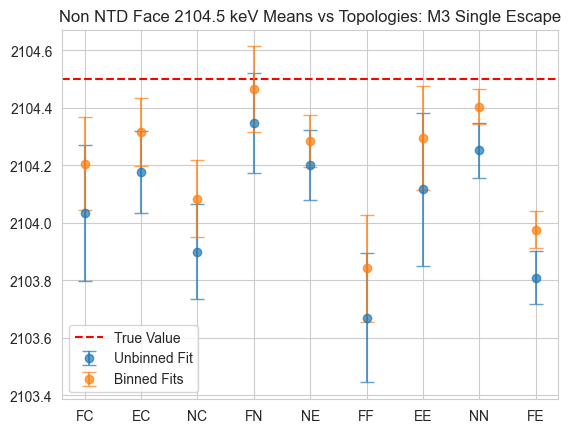

In [101]:
topologies = ['FC', 'EC', 'NC', #'CC', 
              'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
means2 = [2104.205911846127, 2104.3145844803375, 2104.084426357623, 2104.465107585685, 2104.2855898888065, 2103.8422017478038, 2104.2958138488757, 2104.4045414343936, 2103.976859198105]
means = [FCmu_fit, CEmu_fit, NCmu_fit, FNmu_fit, NEmu_fit, FFmu_fit, EEmu_fit, NNmu_fit, FEmu_fit]
y_err = [0.16262468321031628, 0.11828880036572449, 0.13295766945887688, 0.14871453463596745, 0.09071799361863409, 0.1868373087502578, 0.18158863775744935, 0.06075698710019756, 0.06493388836185188]

mu_intersections = [FCintersection_mu, [CEintersection_mu.geoms[0].x, CEintersection_mu.geoms[1].x], 
                    [NCintersection_mu.geoms[0].x, NCintersection_mu.geoms[1].x],  
                    FNintersection_mu, [NEintersection_mu.geoms[0].x, NEintersection_mu.geoms[1].x], 
                    FFintersection_mu, EEintersection_mu,
                   [NNintersection_mu.geoms[0].x, NNintersection_mu.geoms[1].x], [FEintersection_mu.geoms[0].x,FEintersection_mu.geoms[1].x] ]

asymmetric_errormu = Errors(mu_intersections, means)

plt.errorbar(topologies, means, yerr=asymmetric_errormu, capsize=5, fmt='o', label='Unbinned Fit', alpha=0.7)
plt.axhline(y=2104.5, color='r', linestyle='--', label = 'True Value')

plt.errorbar(topologies, means2, yerr=y_err, fmt='o',capsize=5, alpha=0.7, label='Binned Fits')
plt.title('Non NTD Face 2104.5 keV Means vs Topologies: M3 Single Escape')
plt.legend()

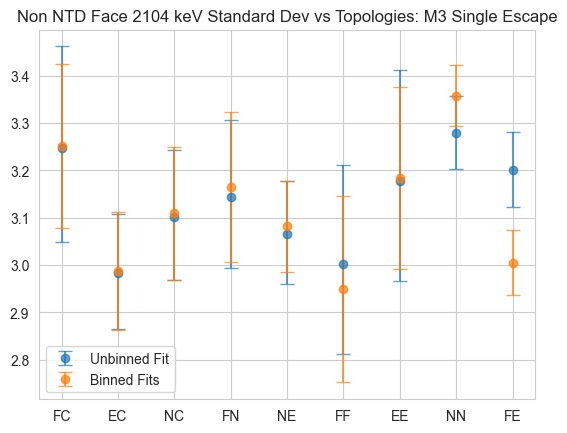

In [102]:
topologies = ['FC', 'EC', 'NC', #'CC', 
              'FN', 'NE', 'FF', 'EE', 'NN', 'FE']
sigmas2 = [3.2507656398885088, 2.9870600660831217, 3.1088719378503282, 3.1649857773830554, 3.081381632072814, 2.948796780354894, 3.1836178297826923, 3.3575221561919903, 3.0048979986577713]
y_err = [0.17276844586047824, 0.12501336776698568, 0.14080457664380866, 0.15783186156960022, 0.09606094408329731, 0.19711356779439534, 0.1929804444085001, 0.06473254294369354, 0.06860170859142893]
sds = [FCsigma_fit, CEsigma_fit, NCsigma_fit, FNsigma_fit, NEsigma_fit, FFsigma_fit, EEsigma_fit, NNsigma_fit, FEsigma_fit]

sigma_intersections = [[FCintersection_sigma.geoms[0].x, FCintersection_sigma.geoms[1].x], [CEintersection_sigma.geoms[0].x, CEintersection_sigma.geoms[1].x], 
                    [NCintersection_sigma.geoms[0].x, NCintersection_sigma.geoms[1].x],  
                    [FNintersection_sigma.geoms[0].x,FNintersection_sigma.geoms[1].x], [NEintersection_sigma.geoms[0].x, NEintersection_sigma.geoms[1].x], 
                    [FFintersection_sigma.geoms[0].x, FFintersection_sigma.geoms[1].x], [EEintersection_sigma.geoms[0].x, EEintersection_sigma.geoms[1].x],
                   [NNintersection_sigma.geoms[0].x, NNintersection_sigma.geoms[1].x], [FEintersection_sigma.geoms[0].x,FEintersection_sigma.geoms[1].x] ]

asymmetric_error = Errors(sigma_intersections, sds)

plt.errorbar(topologies, sds, yerr=asymmetric_error,capsize=5, fmt='o', label='Unbinned Fit', alpha=0.7)
plt.errorbar(topologies, sigmas2,yerr=y_err, fmt='o',capsize=5, alpha=0.7, label='Binned Fits')
plt.title('Non NTD Face 2104 keV Standard Dev vs Topologies: M3 Single Escape')
plt.legend()

In [6]:
def AddSigmaToInt(x):
    s = f"{x:.1f}"
    if s.endswith("0"):
        s = f"{x:.0f}"
    return rf"{s} \-$\sigma$" if plt.rcParams["text.usetex"] else f"{s} -$\sigma$"

def AddSigmaToInt(x):
    sqrtx = np.sqrt(x)
    s = f"{sqrtx:.1f}"
    if s.endswith("0"):
        s = f"{sqrtx:.0f}"
    return f"{s}-$\\sigma$"

def LikelihoodGraphs2D(data, mu_fit, sigma_fit, b_fit, c_fit, title, bplot=False):
    mus = np.linspace(mu_fit+5,mu_fit-5,100)
    sigmas = np.linspace(sigma_fit/2, sigma_fit*2,100)
    bs = np.linspace(b_fit/2, b_fit*2, 100)
    cs = np.linspace(c_fit/2, c_fit*2,100)
    
    if bplot:
        
        muVals_meshgrid, sigmaVals_meshgrid = np.meshgrid(mus, sigmas)
        ZmuVsigma = NegLogLikelihoodGuassExp([muVals_meshgrid, sigmaVals_meshgrid, b_fit, c_fit], data)
        ZmuVsigma_vals = ZmuVsigma - np.min(ZmuVsigma)
        
        fig, ax = plt.subplots(2,3, figsize=(15, 10))
        fig.suptitle(title, y=0.9)
        fig.tight_layout(pad=5.0)
        contour1 = ax[0,0].contourf(muVals_meshgrid, sigmaVals_meshgrid,ZmuVsigma_vals , 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        CS = ax[0,0].contour(muVals_meshgrid, sigmaVals_meshgrid, ZmuVsigma_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,0].clabel(CS, CS.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,0].set_xlabel('$\mu$')
        ax[0,0].set_ylabel('$\sigma$')
        cbar1 = fig.colorbar(contour1, ax=ax[0,0])

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,0].plot(mu_fit, sigma_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,0].set_title('Sigma vs Mu')
        # ax[0,0].set_xlim(2103,2105)
        # ax[0,0].set_ylim(2,4)
        
    ######################
    
        muVals_meshgrid, bVals_meshgrid = np.meshgrid(mus, bs)
        ZmuVb = NegLogLikelihoodGuassExp([muVals_meshgrid, sigma_fit, bVals_meshgrid, c_fit], data)
        ZmuVb_vals = ZmuVb - np.min(ZmuVb)
        
        contour2 = ax[1,0].contourf(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar2 = fig.colorbar(contour2, ax=ax[1,0])
        CS2 = ax[1,0].contour(muVals_meshgrid, bVals_meshgrid, ZmuVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,0].clabel(CS2, CS2.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        plt.grid();
        ax[1,0].set_xlabel('$\mu$')
        ax[1,0].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,0].plot(mu_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,0].set_title('b vs Mu')
    ##################
    
        muVals_meshgrid, cVals_meshgrid = np.meshgrid(mus, cs)
        ZmuVc = NegLogLikelihoodGuassExp([muVals_meshgrid, sigma_fit, b_fit, cVals_meshgrid], data)
        ZmuVc_vals = ZmuVc - np.min(ZmuVc)
    
        contour3 = ax[1,1].contourf(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar3 = fig.colorbar(contour3, ax=ax[1,1])
        CS3 = ax[1,1].contour(muVals_meshgrid, cVals_meshgrid, ZmuVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,1].clabel(CS3, CS3.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,1].set_xlabel('$\mu$')
        ax[1,1].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,1].plot(mu_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,1].set_title('c vs mu')
    ##############
    
        sigmaVals_meshgrid, bVals_meshgrid = np.meshgrid(sigmas, bs)
        ZsigmaVb = NegLogLikelihoodGuassExp([mu_fit, sigmaVals_meshgrid, bVals_meshgrid, c_fit], data)
        ZsigmaVb_vals = ZsigmaVb - np.min(ZsigmaVb)
        
        contour4 = ax[0,1].contourf(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals , 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar4 = fig.colorbar(contour4, ax=ax[0,1])
        CS4 = ax[0,1].contour(sigmaVals_meshgrid, bVals_meshgrid, ZsigmaVb_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,1].clabel(CS4, CS4.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,1].set_xlabel('$\sigma$')
        ax[0,1].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,1].plot(sigma_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,1].set_title('b vs Sigma')
    ##############
        sigmaVals_meshgrid, cVals_meshgrid = np.meshgrid(sigmas, cs)
        ZsigmaVc = NegLogLikelihoodGuassExp([mu_fit, sigmaVals_meshgrid, b_fit, cVals_meshgrid], data)
        ZsigmaVc_vals = ZsigmaVc - np.min(ZsigmaVc)
    
        contour5 = ax[0,2].contourf(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar5 = fig.colorbar(contour5, ax=ax[0,2])
        CS5 = ax[0,2].contour(sigmaVals_meshgrid, cVals_meshgrid, ZsigmaVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[0,2].clabel(CS5, CS5.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[0,2].set_xlabel('$\sigma$')
        ax[0,2].set_ylabel('$c = C/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[0,2].plot(sigma_fit, c_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[0,2].set_title('c vs Sigma')
    ##############
        cVals_meshgrid, bVals_meshgrid = np.meshgrid(cs, bs)
        ZbVc = NegLogLikelihoodGuassExp([mu_fit, sigma_fit, bVals_meshgrid, cVals_meshgrid], data)
        ZbVc_vals = ZbVc - np.min(ZbVc)
    
        contour6 = ax[1,2].contourf(cVals_meshgrid, bVals_meshgrid,ZbVc_vals, 100, cmap='tab20b',linestyles ='None', alpha=0.7)
        cbar6 = fig.colorbar(contour6, ax=ax[1,2])
        CS6 = ax[1,2].contour(cVals_meshgrid, bVals_meshgrid, ZbVc_vals, levels=[0.0001, 1, 4, 9, 25, 100], cmap='Pastel1')

        ax[1,2].clabel(CS6, CS6.levels, inline=True, fmt=AddSigmaToInt, fontsize=10)
        ax[1,2].set_xlabel('$c = C/A$')
        ax[1,2].set_ylabel('$b = B/A$')

        #plt.plot(mu, sigma, marker="o", markersize=10, markeredgecolor="cyan", markerfacecolor="blue", label='1D Loglikelihood') #this line does not apply since you already have data
        ax[1,2].plot(c_fit, b_fit, marker="o", markersize=5, color="cyan", label='Best Fit Value')
        ax[1,2].set_title('c vs b')
        
        plt.show()